# Nevergrad test

In [1]:
import nevergrad as ng
import matplotlib.pyplot as plt
import numpy as np
import copy
import time
from pathlib import Path

from qiskit.circuit import Parameter

from modules.helper_functions_tsp import (
        find_problem_size, 
        find_distances_array,
        cost_fn_fact,
        cost_func_evaluate, 
        bind_weights,
        vqc_circuit,
        define_parameters,
        create_initial_rotations,
        find_sdk,
        find_local_quantum,
        calculate_hot_start_data,
        find_optimiser_function,
        find_nevergrad_optimizers,
        )

from modules.quantum_circuits import print_quantum_circuits

from typing import Callable             # for function docs.
from braket.circuits import Circuit     # for function docs.

from classes.MyDataLogger import MyDataLogger, MySubDataLogger

from modules.config import(
        SLICES,       
        )     

Set up datalogger and sub-datalogger.  No results are logged against this first datalogger.  The aim is to set up the quantum circuit.

In [2]:
datalogger = MyDataLogger()
sdl = MySubDataLogger(runid = datalogger.runid)
sdl.update_general_constants_from_config()
sdl.update_quantum_constants_from_config()
sdl.validate_input()

SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-36-29


Check that there are not multiple slices read from the parameter file.

In [3]:
if len(SLICES) != 1:
    raise ValueError(f'{SLICES=} should only contain one value for this notebook, {len(SLICES)} found.') 
slice = SLICES[0]
sdl.slice = slice

Validate target and print out relevant information.

In [4]:
if not find_local_quantum(sdl.target):
    raise Exception(f'Notebook is only written for AWS or Qiskit to be run locally and {sdl.target=}')
sdk_type = find_sdk(sdl.target)
print(f' Running notebook for {sdl.target=}, {sdl.aws=}, {sdk_type=}')
print(f' with {sdl.mps=}, {sdl.slice=},')

 Running notebook for sdl.target='local_qiskit', sdl.aws=False, sdk_type='qiskit'
 with sdl.mps=True, sdl.slice=1.0,


Find number of qubits and set up distance array.

In [5]:
np.random.seed(42)

sdl.qubits = find_problem_size(
    locations=sdl.locations,
    formulation=sdl.formulation
)
print(f'There are {sdl.qubits} logical qubits needed for {sdl.locations} locations in the {sdl.formulation} formulation.')
print(f'Running mode {sdl.mode} with {sdl.shots} shots')

distance_array, best_dist = find_distances_array(sdl.locations, print_comments=True)

There are 8 logical qubits needed for 6 locations in the original formulation.
Running mode 2 with 1024 shots
Reading distance data
Data will be read from filename networks\sim_dist_6_locs.txt.
It is known that the shortest distance is 241.0


Set up and print quantum circuit.

Number of parameters to be optimized is 16
After measurement, the following qubits are measured [0, 1, 2, 3, 4, 5, 6, 7]


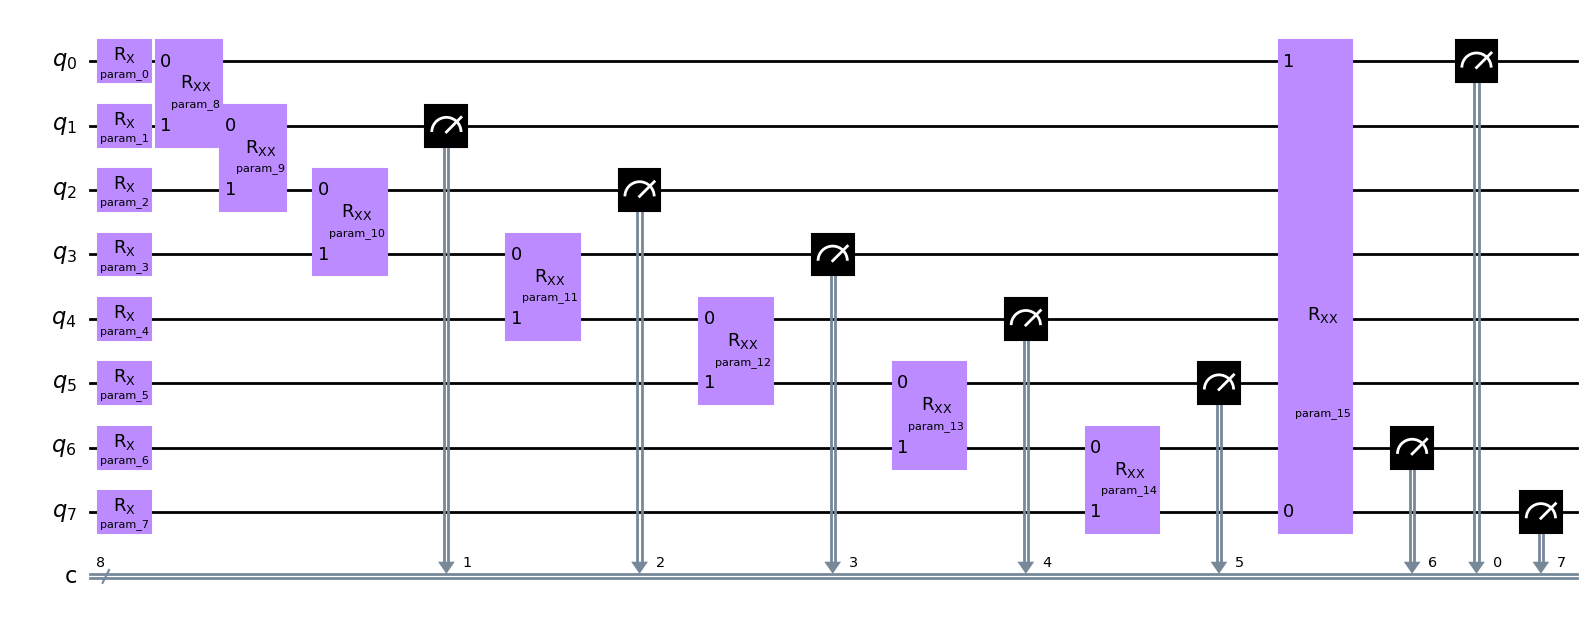

In [6]:
num_params = sdl.calculate_parameter_numbers()
print(f'Number of parameters to be optimized is {num_params}')
params = define_parameters(
    mode=sdl.mode,
    num_params=num_params,
    target=sdl.target,
    )
#print(f'Parameters are: {params}')
qc = vqc_circuit(
    qubits=sdl.qubits,
    mode=sdl.mode,
    noise_bool=sdl.noise,
    layers=sdl.layers,
    params=params,
    target=sdl.target,
    )
filename = Path.joinpath(datalogger.graph_sub_path, f'initial_unbound_circuit{sdl.mode}.pdf')
print_quantum_circuits(
    qubits=sdl.qubits,
    sdk_type=sdk_type,
    qc=qc,
    filename=filename,
    )

Set up the cost_fn using the factory.  This takes a bit string and returns a distance.

In [7]:
cost_fn = cost_fn_fact(
    locations=sdl.locations,
    qubits=sdl.qubits,
    gray=sdl.gray,
    formulation=sdl.formulation,
    distance_array=distance_array,
    target=sdl.target
    )

Set up the initial parameters, either from the hot start, or from random, bind to the quantum circuit, and print out if the circuit is small.

The initial parameters (weights) are [3.45083002 0.77783106 0.47265613 2.71489485 6.04473805 0.76874521
 4.68970562 0.45627645 3.85112512 5.68338017 5.39767081 4.61766916
 6.05057456 5.76024114 5.54592853 3.3396131 ]


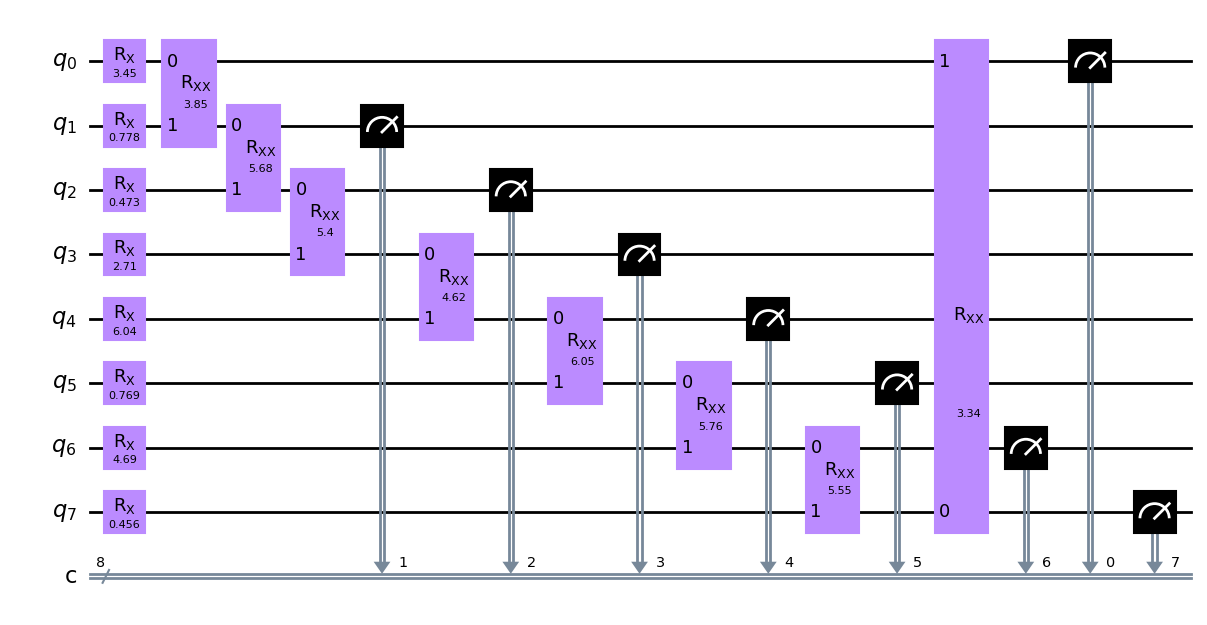

In [8]:
bin_hot_start_list=[]
if sdl.hot_start:
    match sdk_type:
        case 'aws':
            raise Exception(f'The hot start list cannot be run at the moment with AWS circuits.  {sdl.hot_start=}')
        case 'qiskit':
            bin_hot_start_list, hot_start_distance = calculate_hot_start_data(
                sdl=sdl, 
                distance_array=distance_array,
                cost_fn=cost_fn,
                print_results=True,
                )
        case '_':
            raise Exception(f'{sdk_type=} is not defined.')

init_rots = create_initial_rotations(
    qubits=sdl.qubits,
    num_params=num_params,
    target=sdl.target,
    hot_start=sdl.hot_start,
    bin_hot_start_list=bin_hot_start_list,
    )

print(f'The initial parameters (weights) are {init_rots}')
bc = bind_weights(
    params=params, 
    rots=init_rots, 
    qc=qc,
    target=sdl.target,
    )
filename = Path.joinpath(datalogger.graph_sub_path, f'initial_bound_circuit{sdl.mode}.pdf')

if sdl.qubits < 15:
    print_quantum_circuits(
        qubits=sdl.qubits,
        sdk_type=sdk_type,
        qc=bc,
        filename=filename
        )

Set up the factory that makes the nevergrad cost function, that receives a delta, and returns the cost, and the lowest distance found.

Caution:  need to be wary of this function returing two arguments.


In [9]:
def ng_cost_function_fact(
    qc:Circuit,
    target:str,
    noise_bool:bool,
    shots:int,
    cost_fn:Callable,
    mps:bool,
    params:Parameter,
    init_rots:np.array,
    )->float:
    """returns a cost function for Nevergrad depending only on rotations"""
    def ng_cost_function(delta:np.array)-> float:

        rots = init_rots+delta
        rots = np.mod(rots, 2*np.pi)   # handle periodicity

        bc = bind_weights(
            params=params, 
            rots=rots, 
            qc=qc,
            target=target,
        )
        cost, lowest, _ = cost_func_evaluate(
            noise_bool=noise_bool,
            shots=shots,
            cost_fn=cost_fn,
            model=bc,
            target=target,
            mps=mps,
            average_slice=1,
        )    
        return cost, lowest
    return ng_cost_function

Generate the Nevergrad cost function from the factory.

In [10]:
ng_cost_function =  ng_cost_function_fact(
    qc=qc,
    target=sdl.target,
    noise_bool=sdl.noise,
    shots=sdl.shots,
    cost_fn=cost_fn,
    mps=sdl.mps,
    params=params,
    init_rots=init_rots,
    )

cost = ng_cost_function(init_rots)

Find the Nevergrad optimisers

In [11]:
nevergrad_optimizers_dict = find_nevergrad_optimizers()

Loop round parameters of interest, print out and save graphs and results.

SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-36-31
The time taken to run the code is 1.37 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-36-31 successfully added to results\20260601-15-36-29\15-36-31.csv
SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-36-33
The time taken to run the code is 1.35 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-36-33 successfully added to results\20260601-15-36-29\15-36-33.csv
SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-36-34
The time taken to run the code is 1.45 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-36-34 successfully added to results\20260601-15-36-29\15-36-34.csv
SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-36-36
The time taken to run the code is 1.42 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-36-36 s

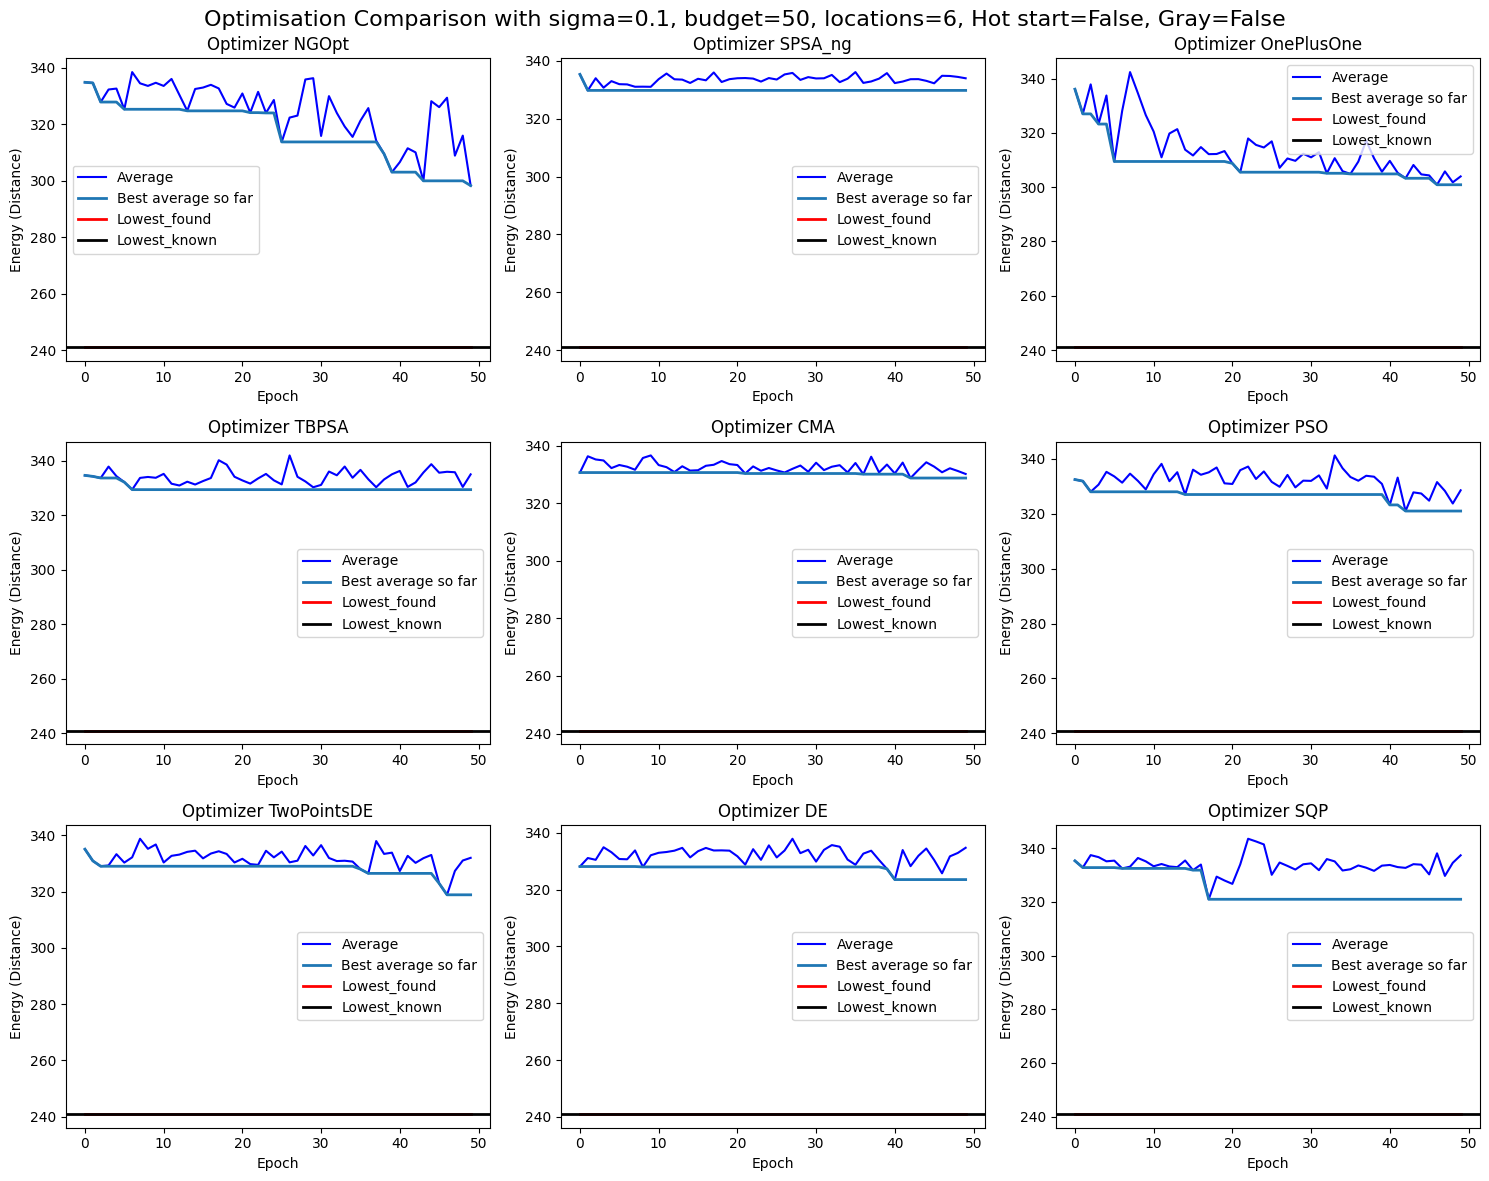

SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-36-47
The time taken to run the code is 1.80 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-36-47 successfully added to results\20260601-15-36-29\15-36-47.csv
SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-36-49
The time taken to run the code is 1.66 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-36-49 successfully added to results\20260601-15-36-29\15-36-49.csv
SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-36-50
The time taken to run the code is 1.71 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-36-50 successfully added to results\20260601-15-36-29\15-36-50.csv
SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-36-52
The time taken to run the code is 1.85 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-36-52 s

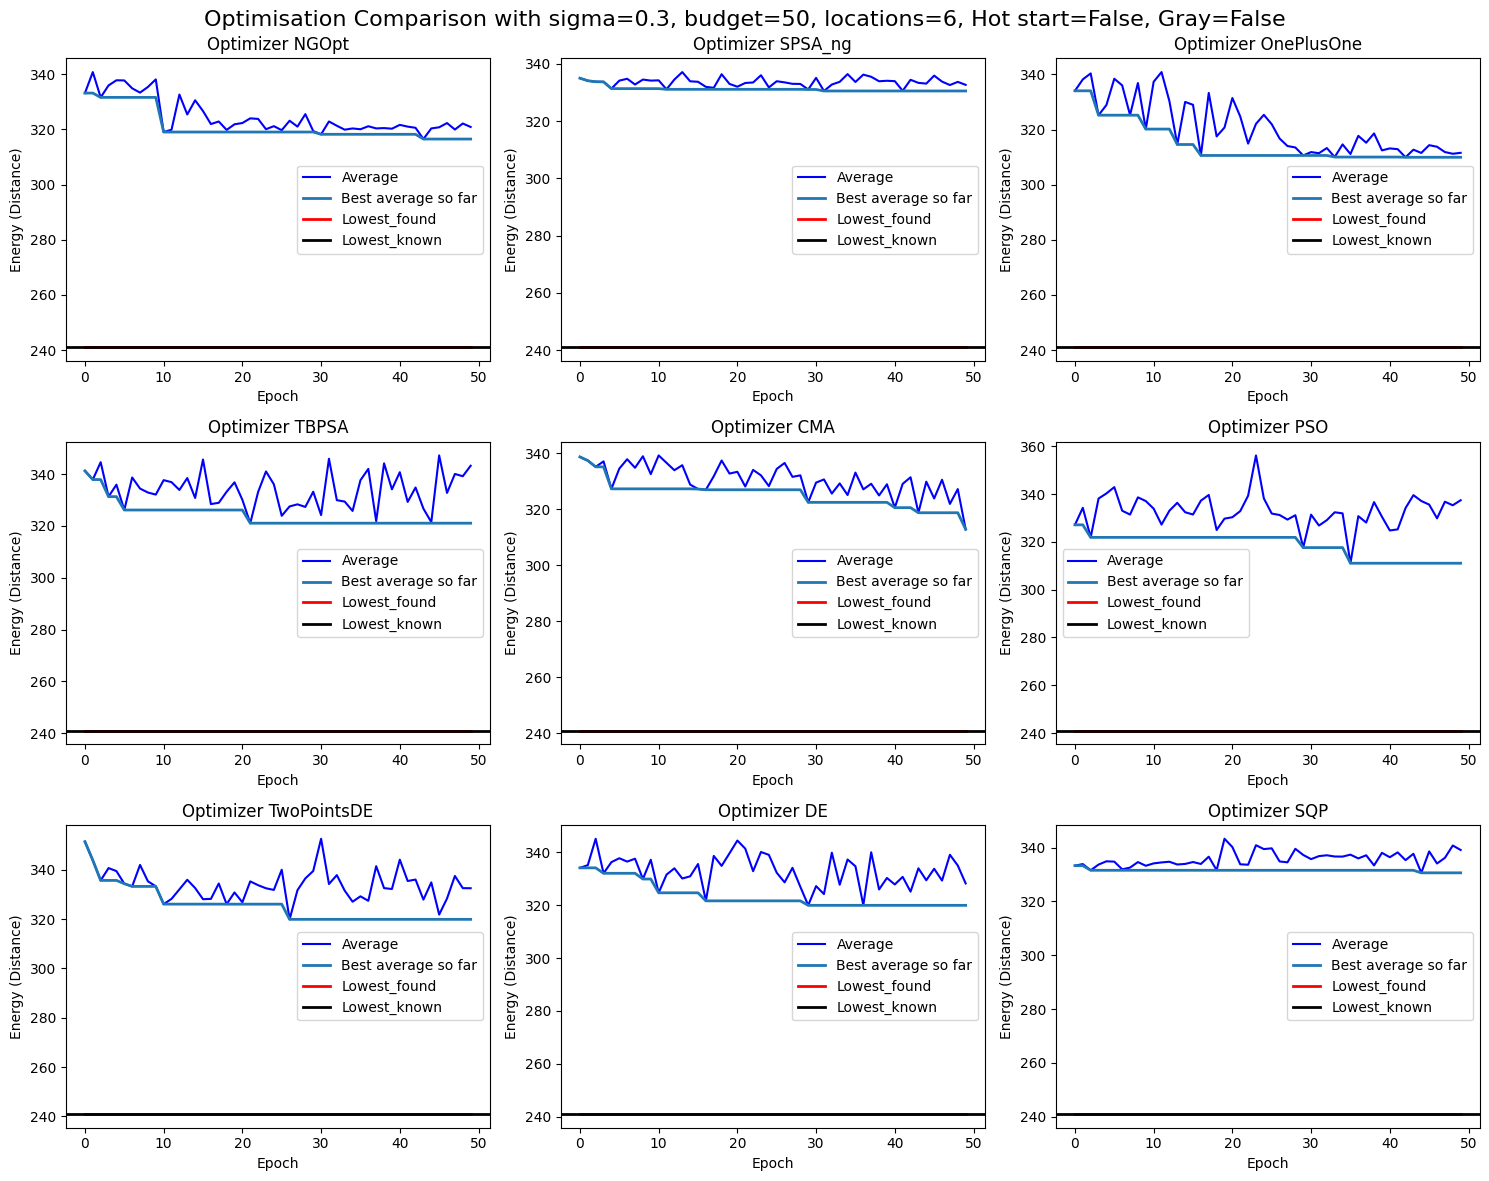

SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-37-05
The time taken to run the code is 1.75 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-37-05 successfully added to results\20260601-15-36-29\15-37-05.csv
SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-37-07
The time taken to run the code is 1.76 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-37-07 successfully added to results\20260601-15-36-29\15-37-07.csv
SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-37-09
The time taken to run the code is 1.80 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-37-09 successfully added to results\20260601-15-36-29\15-37-09.csv
SubDataLogger instantiated.  Run ID = 20260601-15-36-29 - 15-37-11
The time taken to run the code is 1.78 seconds
Saving data to results\results.csv
Detailed data for Run ID: 20260601-15-36-29 - 15-37-11 s

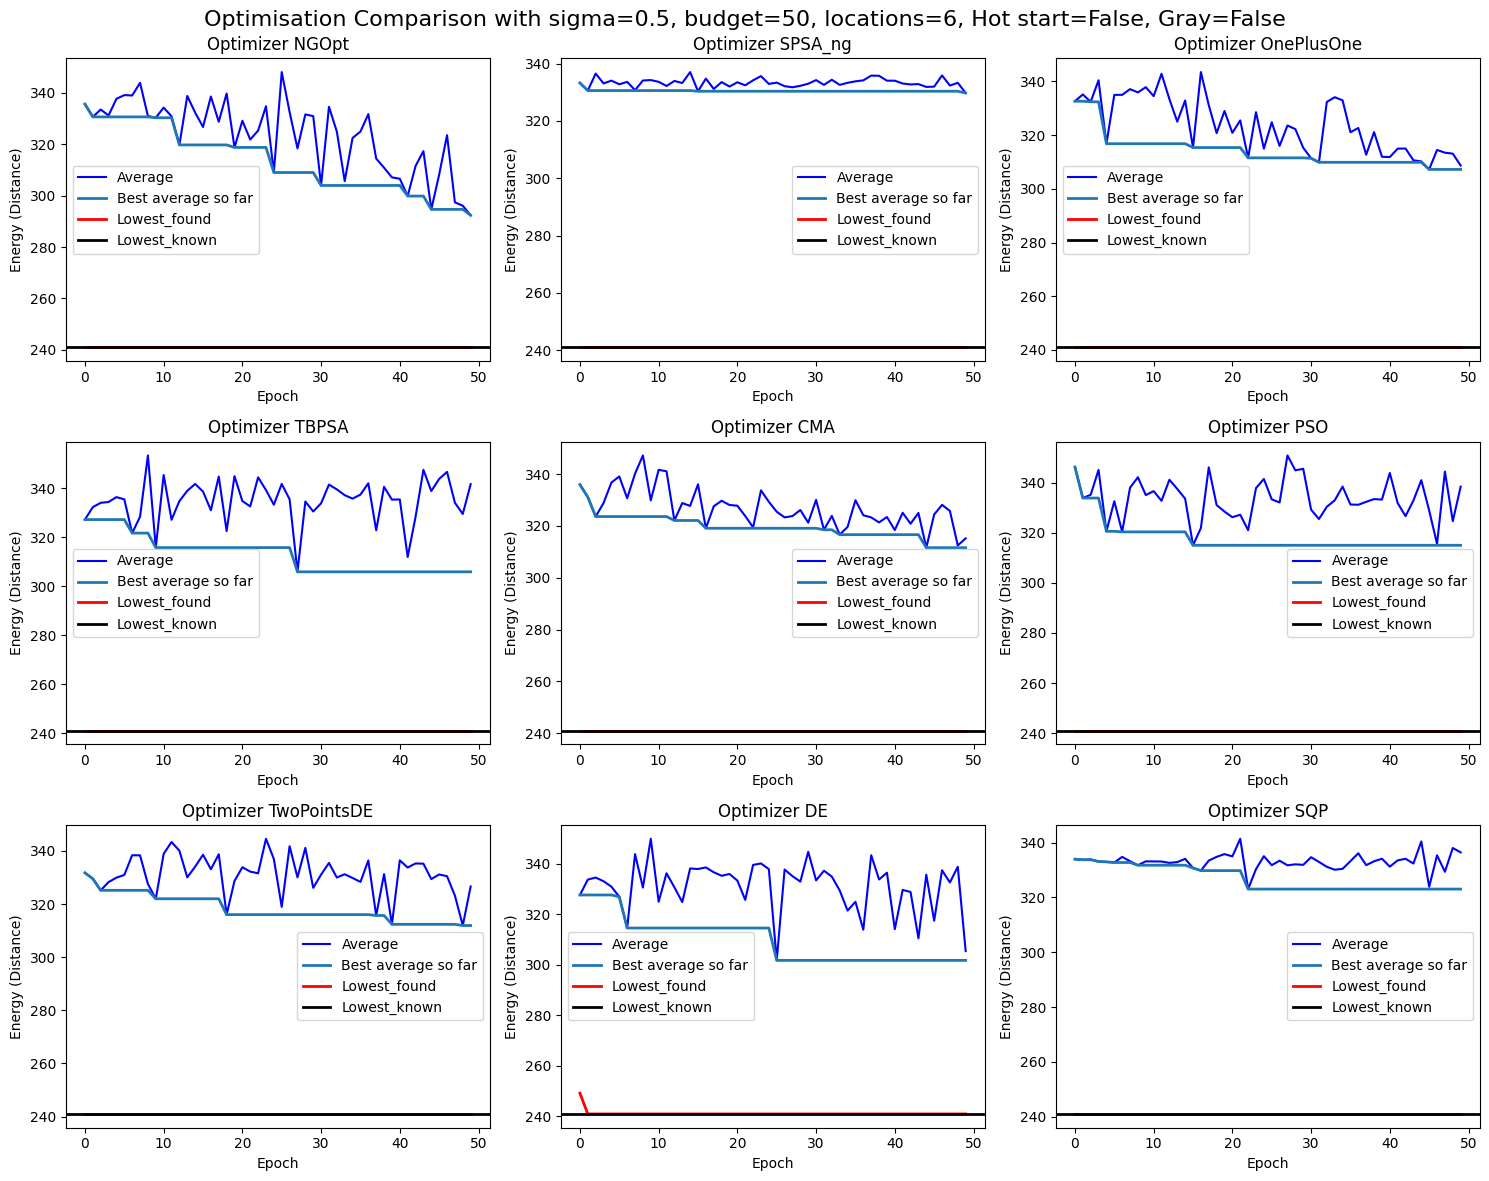

In [12]:
for SIGMA in [0.1, 0.3, 0.5]:    
    instrum = ng.p.Instrumentation(
    ng.p.Array(shape=(num_params,))
        .set_mutation(sigma=SIGMA)
)
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()  # makes indexing easier

    title = (
        f'Optimisation Comparison with sigma={SIGMA}, '
        f'budget={sdl.iterations}, locations={sdl.locations}, '
        f'Hot start={sdl.hot_start}, Gray={sdl.gray}'
    )
    filepath = Path(datalogger.graph_sub_path).joinpath(f"{title}.pdf")
    fig.suptitle(
        title,
        fontsize=16
    )
    for idx, optimizer_name in enumerate(nevergrad_optimizers_dict):
        ax = axes[idx]  # select subplot
        t0 = time.time()
        #need new sdl for each run
        sdl = MySubDataLogger(runid = datalogger.runid)
        sdl.update_general_constants_from_config()
        sdl.update_quantum_constants_from_config()
        sdl.validate_input()
        sdl.num_params = num_params
        sdl.slice = slice
        sdl.sigma = SIGMA
        if sdl.hot_start:
            sdl.hot_start_dist = hot_start_distance
        else:
            sdl.hot_start_dist = 'n/a'
        optimzer_function = find_optimiser_function(optimizer_name)
        optimizer = optimzer_function(
            parametrization=instrum,
            budget=sdl.iterations,
        )    
        #values, best_values, lowest_values = [], [], []
        sdl.average_list, sdl_lowest_list, sdl.best_av_list = [], [], []
        sdl.index_list = [i for i in range(sdl.iterations)]

        #recommendation = optimizer.parametrization.spawn_child()
        best_av_to_date = float('inf')
        best_dist_found  = float('inf')

        for i in range(optimizer.budget):
            candidate = optimizer.ask()
            x = candidate.args[0]
            value, lowest = ng_cost_function(x)
            optimizer.tell(candidate, value)
            sdl.average_list.append(value)
            best_av_to_date= min(best_av_to_date,value)
            best_dist_found = min(best_dist_found,lowest)
            sdl.best_av_list.append(best_av_to_date)
            sdl.lowest_list.append(best_dist_found)
        
        #prepare sub-graph
        ax.plot(sdl.average_list, color='blue', label='Average', )
        ax.plot(sdl.best_av_list, label='Best average so far', linewidth=2)
        ax.plot(sdl.lowest_list, color='red', linewidth=2 ,label='Lowest_found')
        ax.axhline(best_dist, color='black', linewidth=2, label='Lowest_known')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Energy (Distance)')
        ax.legend()
        title = str(f'Optimizer {optimizer_name}')
        ax.set_title(title)

        #update and save sub-data logger details
        t1 = time.time()
        elapsed = t1-t0
        print(f'The time taken to run the code is {elapsed:.2f} seconds')
        sdl.elapsed = elapsed

        sdl.last_av = value
        sdl.best_dist_found=best_dist_found
        sdl.best_dist = best_dist
        sdl.best_av_to_date = best_av_to_date
        sdl.gradient_type = optimizer_name
        sdl.update_cache_statistics(cost_fn)
        sdl.save_results_to_csv()
        sdl.save_detailed_results()

    #plot main graph, with sub-plots by optimiser
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.tight_layout()
    print(f'Saving graph to {filepath}')
    plt.savefig(filepath)
    plt.show()
